In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("PyTorch :", torch.__version__)
print("GPU disponible :", torch.cuda.is_available())
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device :", device)

PyTorch : 2.10.0+cu128
GPU disponible : True
Device : cuda


In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = torchvision.datasets.MNIST(root='./data', train=True,
                                            download=True, transform=transform)
test_dataset  = torchvision.datasets.MNIST(root='./data', train=False,
                                            download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False)

print(f"Taille train : {len(train_dataset)} images")
print(f"Taille test  : {len(test_dataset)} images")
print(f"Forme d'une image : {train_dataset[0][0].shape}")

100%|██████████| 9.91M/9.91M [00:00<00:00, 19.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 478kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.47MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 3.15MB/s]

Taille train : 60000 images
Taille test  : 10000 images
Forme d'une image : torch.Size([1, 28, 28])


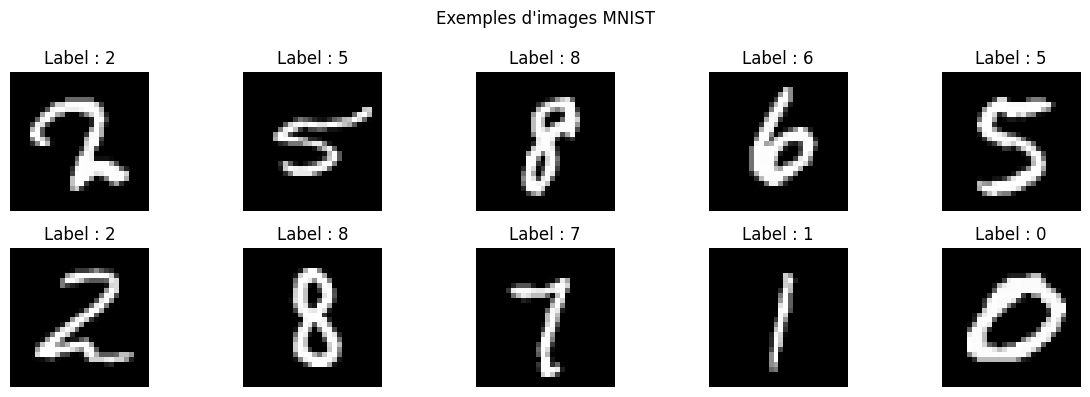

Forme d'un batch : torch.Size([64, 1, 28, 28])


In [ ]:
images, labels = next(iter(train_loader))

plt.figure(figsize=(12, 4))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(images[i].squeeze(), cmap='gray')
    plt.title(f"Label : {labels[i].item()}")
    plt.axis('off')
plt.suptitle("Exemples d'images MNIST")
plt.tight_layout()
plt.show()

print(f"Forme d'un batch : {images.shape}")

In [ ]:
def conv_output_size(input_size, kernel_size, padding=0, stride=1):
    return (input_size + 2*padding - kernel_size) // stride + 1

def pool_output_size(input_size, kernel_size, stride=None):
    if stride is None:
        stride = kernel_size
    return (input_size - kernel_size) // stride + 1

print("=== Calculs dimensionnels pour MNIST (28x28) ===\n")

s1 = conv_output_size(28, kernel_size=5, padding=2)
print(f"Après Conv1 (k=5, p=2)     : {s1}x{s1}")

s2 = pool_output_size(s1, kernel_size=2)
print(f"Après MaxPool1 (k=2, s=2)  : {s2}x{s2}")

s3 = conv_output_size(s2, kernel_size=5, padding=0)
print(f"Après Conv2 (k=5, p=0)     : {s3}x{s3}")

s4 = pool_output_size(s3, kernel_size=2)
print(f"Après MaxPool2 (k=2, s=2)  : {s4}x{s4}")

print(f"\nTaille aplatie finale : 16 × {s4} × {s4} = {16*s4*s4} neurones")

=== Calculs dimensionnels pour MNIST (28x28) ===

Après Conv1 (k=5, p=2)     : 28x28
Après MaxPool1 (k=2, s=2)  : 14x14
Après Conv2 (k=5, p=0)     : 10x10
Après MaxPool2 (k=2, s=2)  : 5x5

Taille aplatie finale : 16 × 5 × 5 = 400 neurones


In [2]:
import numpy as np
import torch.nn.functional as F
import torch

def correlation_croisee_2d(input_map, kernel):
    """Implémentation manuelle de la corrélation croisée 2D"""
    h_in, w_in = input_map.shape
    h_k, w_k = kernel.shape
    h_out = h_in - h_k + 1
    w_out = w_in - w_k + 1
    output = np.zeros((h_out, w_out))
    for i in range(h_out):
        for j in range(w_out):
            output[i, j] = np.sum(input_map[i:i+h_k, j:j+w_k] * kernel)
    return output

input_test  = np.array([[1,2,3],[4,5,6],[7,8,9]], dtype=float)
kernel_test = np.array([[1,0],[-1,1]], dtype=float)

result = correlation_croisee_2d(input_test, kernel_test)
print("Input :\n", input_test)
print("\nKernel :\n", kernel_test)
print("\nRésultat corrélation croisée :\n", result)


input_torch  = torch.FloatTensor(input_test).unsqueeze(0).unsqueeze(0)
kernel_torch = torch.FloatTensor(kernel_test).unsqueeze(0).unsqueeze(0)
result_torch = F.conv2d(input_torch, kernel_torch)
print("\nRésultat PyTorch :\n", result_torch.squeeze().numpy())
print("\nIdentiques :", np.allclose(result, result_torch.squeeze().numpy()))

Input :
 [[1. 2. 3.]
 [4. 5. 6.]
 [7. 8. 9.]]

Kernel :
 [[ 1.  0.]
 [-1.  1.]]

Résultat corrélation croisée :
 [[2. 3.]
 [5. 6.]]

Résultat PyTorch :
 [[2. 3.]
 [5. 6.]]

Identiques : True


In [3]:
def max_pooling_2d(input_map, kernel_size=2, stride=2):
    h_in, w_in = input_map.shape
    h_out = (h_in - kernel_size) // stride + 1
    w_out = (w_in - kernel_size) // stride + 1
    output = np.zeros((h_out, w_out))
    for i in range(h_out):
        for j in range(w_out):
            output[i,j] = np.max(input_map[i*stride:i*stride+kernel_size,
                                           j*stride:j*stride+kernel_size])
    return output

def avg_pooling_2d(input_map, kernel_size=2, stride=2):
    h_in, w_in = input_map.shape
    h_out = (h_in - kernel_size) // stride + 1
    w_out = (w_in - kernel_size) // stride + 1
    output = np.zeros((h_out, w_out))
    for i in range(h_out):
        for j in range(w_out):
            output[i,j] = np.mean(input_map[i*stride:i*stride+kernel_size,
                                            j*stride:j*stride+kernel_size])
    return output

test_map = np.array([[1,3,2,4],[5,6,7,8],[3,2,1,0],[9,1,2,3]], dtype=float)
print("Input :\n", test_map)
print("\nMax Pooling (2x2) :\n", max_pooling_2d(test_map))
print("\nAverage Pooling (2x2) :\n", avg_pooling_2d(test_map))

Input :
 [[1. 3. 2. 4.]
 [5. 6. 7. 8.]
 [3. 2. 1. 0.]
 [9. 1. 2. 3.]]

Max Pooling (2x2) :
 [[6. 8.]
 [9. 3.]]

Average Pooling (2x2) :
 [[3.75 5.25]
 [3.75 1.5 ]]


In [6]:
import torch
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class LeNet(nn.Module):
    def __init__(self):
        super(LeNet, self).__init__()
        # Bloc convolutionnel 1
        self.conv1 = nn.Conv2d(1, 6, kernel_size=5, padding=2)
        self.pool1 = nn.AvgPool2d(kernel_size=2, stride=2)
        # Bloc convolutionnel 2
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5)
        self.pool2 = nn.AvgPool2d(kernel_size=2, stride=2)
        # Couches fully connected
        self.fc1 = nn.Linear(16*5*5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = torch.sigmoid(self.conv1(x))
        x = self.pool1(x)
        x = torch.sigmoid(self.conv2(x))
        x = self.pool2(x)
        x = x.view(-1, 16*5*5)   # aplatir
        x = torch.sigmoid(self.fc1(x))
        x = torch.sigmoid(self.fc2(x))
        x = self.fc3(x)
        return x

lenet = LeNet().to(device)
print(lenet)
print(f"\nNombre de paramètres : {sum(p.numel() for p in lenet.parameters()):,}")

LeNet(
  (conv1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (pool1): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (pool2): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)

Nombre de paramètres : 61,706


In [8]:
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import torch.nn as nn
import torch

# Assuming 'device' and 'lenet' are defined in prior executed cells, or handled by current context.
# For example, if you ran the previous cell 'e3hE2r39STwO', 'lenet' and 'device' would be available.

# Data transformations
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Load datasets
train_dataset = torchvision.datasets.MNIST(root='./data', train=True,
                                            download=True, transform=transform)
test_dataset  = torchvision.datasets.MNIST(root='./data', train=False,
                                            download=True, transform=transform)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(lenet.parameters(), lr=0.001)

num_epochs = 10
train_losses, test_accuracies = [], []

for epoch in range(num_epochs):
    lenet.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = lenet(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    train_losses.append(avg_loss)

    # Évaluation
    lenet.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = lenet(images)
            predicted = torch.argmax(outputs, dim=1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    acc = correct / total
    test_accuracies.append(acc)
    print(f"Époque {epoch+1:2d}/10 | Loss: {avg_loss:.4f} | Accuracy: {acc:.4f}")

torch.save(lenet.state_dict(), "lenet_mnist.pth")
print("\nModèle sauvegardé ✅")

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 458kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.43MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 14.2MB/s]


Époque  1/10 | Loss: 1.0198 | Accuracy: 0.9216
Époque  2/10 | Loss: 0.2190 | Accuracy: 0.9551
Époque  3/10 | Loss: 0.1390 | Accuracy: 0.9707
Époque  4/10 | Loss: 0.1030 | Accuracy: 0.9767
Époque  5/10 | Loss: 0.0842 | Accuracy: 0.9763
Époque  6/10 | Loss: 0.0719 | Accuracy: 0.9773
Époque  7/10 | Loss: 0.0628 | Accuracy: 0.9798
Époque  8/10 | Loss: 0.0553 | Accuracy: 0.9835
Époque  9/10 | Loss: 0.0507 | Accuracy: 0.9831
Époque 10/10 | Loss: 0.0464 | Accuracy: 0.9841

Modèle sauvegardé ✅


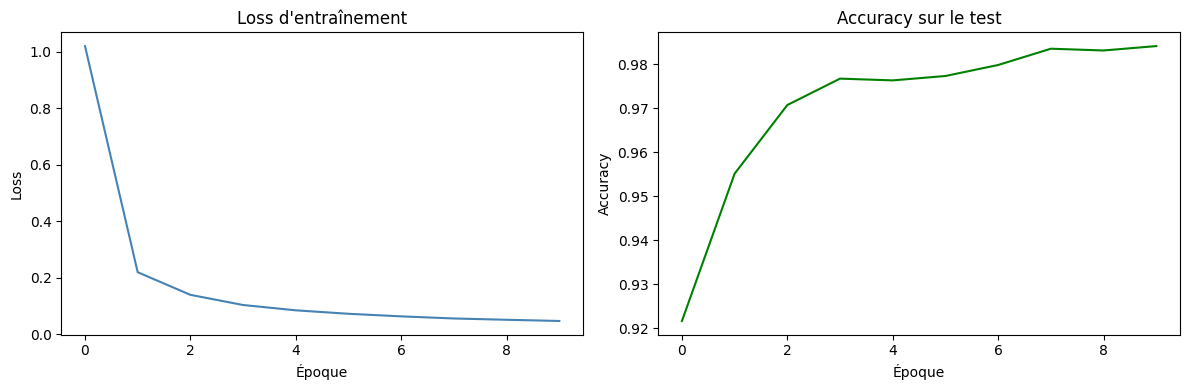

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses, color='steelblue')
plt.title("Loss d'entraînement")
plt.xlabel("Époque")
plt.ylabel("Loss")

plt.subplot(1, 2, 2)
plt.plot(test_accuracies, color='green')
plt.title("Accuracy sur le test")
plt.xlabel("Époque")
plt.ylabel("Accuracy")

plt.tight_layout()
plt.show()

=== Rapport de classification ===
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       0.99      1.00      0.99      1135
           2       0.99      0.99      0.99      1032
           3       0.99      0.98      0.98      1010
           4       0.98      0.99      0.98       982
           5       0.98      0.99      0.98       892
           6       0.98      0.99      0.99       958
           7       0.99      0.96      0.98      1028
           8       0.99      0.98      0.98       974
           9       0.97      0.98      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



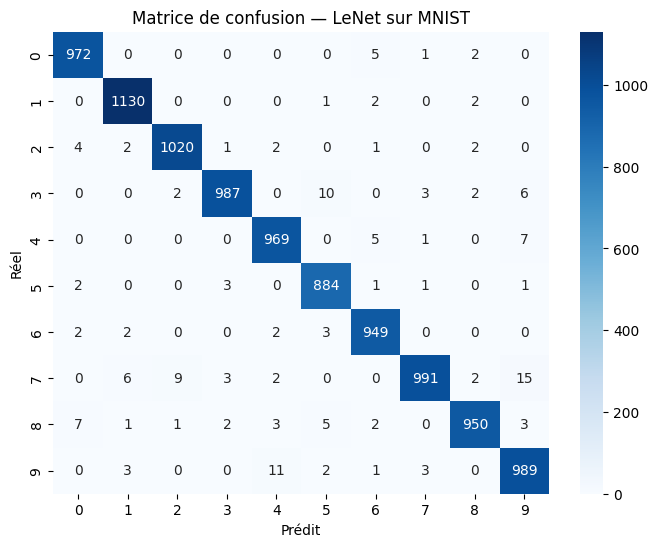

In [12]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

lenet.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = lenet(images)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

print("=== Rapport de classification ===")
print(classification_report(all_labels, all_preds,
      target_names=[str(i) for i in range(10)]))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Matrice de confusion — LeNet sur MNIST")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.show()

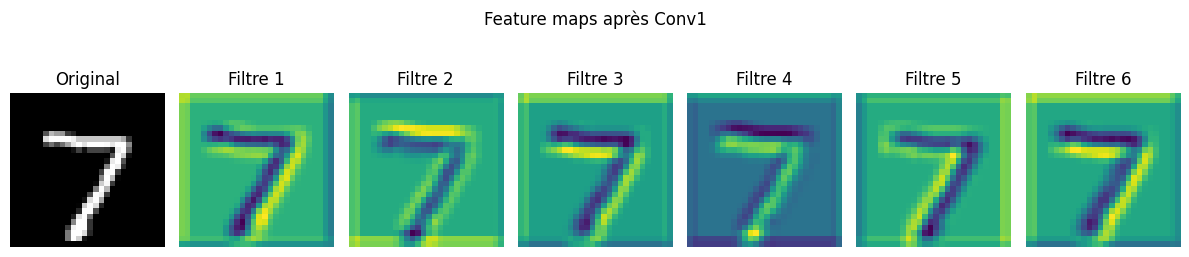

In [13]:
# Prendre une image du test
img, label = test_dataset[0]
img_tensor = img.unsqueeze(0).to(device)

# Extraire les feature maps après conv1
activation = {}
def get_activation(name):
    def hook(model, input, output):
        activation[name] = output.detach()
    return hook

lenet.conv1.register_forward_hook(get_activation('conv1'))
_ = lenet(img_tensor)

feature_maps = activation['conv1'].squeeze().cpu()

plt.figure(figsize=(12, 3))
plt.subplot(1, 7, 1)
plt.imshow(img.squeeze(), cmap='gray')
plt.title("Original")
plt.axis('off')

for i in range(6):
    plt.subplot(1, 7, i+2)
    plt.imshow(feature_maps[i], cmap='viridis')
    plt.title(f"Filtre {i+1}")
    plt.axis('off')

plt.suptitle("Feature maps après Conv1")
plt.tight_layout()
plt.show()

MLP Époque 1/10 | Accuracy: 0.9460
MLP Époque 2/10 | Accuracy: 0.9600
MLP Époque 3/10 | Accuracy: 0.9610
MLP Époque 4/10 | Accuracy: 0.9718
MLP Époque 5/10 | Accuracy: 0.9710
MLP Époque 6/10 | Accuracy: 0.9748
MLP Époque 7/10 | Accuracy: 0.9738
MLP Époque 8/10 | Accuracy: 0.9734
MLP Époque 9/10 | Accuracy: 0.9769
MLP Époque 10/10 | Accuracy: 0.9771


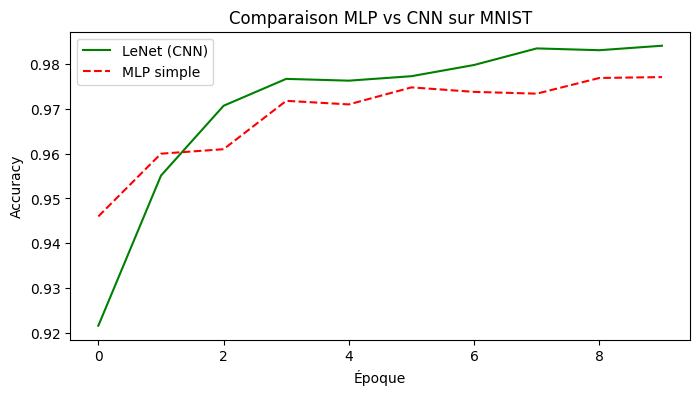


Meilleure accuracy CNN : 0.9841
Meilleure accuracy MLP : 0.9771


In [14]:
# MLP simple pour images
class MLP_Images(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(28*28, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 10)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = x.view(-1, 28*28)  # aplatir l'image
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        return self.fc3(x)

mlp_img = MLP_Images().to(device)
optimizer_mlp = torch.optim.Adam(mlp_img.parameters(), lr=0.001)

mlp_accuracies = []
for epoch in range(10):
    mlp_img.train()
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer_mlp.zero_grad()
        loss = criterion(mlp_img(images), labels)
        loss.backward()
        optimizer_mlp.step()

    mlp_img.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            preds = torch.argmax(mlp_img(images), dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    mlp_accuracies.append(correct/total)
    print(f"MLP Époque {epoch+1}/10 | Accuracy: {correct/total:.4f}")

# Comparaison finale
plt.figure(figsize=(8, 4))
plt.plot(test_accuracies, label='LeNet (CNN)', color='green')
plt.plot(mlp_accuracies, label='MLP simple', color='red', linestyle='--')
plt.title("Comparaison MLP vs CNN sur MNIST")
plt.xlabel("Époque")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

print(f"\nMeilleure accuracy CNN : {max(test_accuracies):.4f}")
print(f"Meilleure accuracy MLP : {max(mlp_accuracies):.4f}")